# PCO213 — Trabalho Final


---

**Roteiro das seções**

| Seção | Objetivo |
|-------|----------|
| 1 | Limpar e estruturar os dados |
| 2 | Explorar distribuições e relações (EDA) |
| 2.5 | PCA — visão multivariada |
| 3–4 | Treinar e avaliar modelos |
| 5–6 | Comparar e interpretar resultados |
| 7 | Conclusões |


In [1]:
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_validate, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
%matplotlib inline

RANDOM_STATE = 42
DATA_PATH = Path("datasets/Car details v3.csv")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)


### Como ler este notebook

Este notebook está organizado em etapas. Em cada seção você encontrará:
1. **Texto explicativo** — o que estamos fazendo e por quê.
2. **Código** — execução da análise.
3. **Orientação de leitura** — como interpretar tabelas e gráficos logo abaixo.

> Dica: execute as células em ordem. Os gráficos só fazem sentido depois que a limpeza (seção 1) for concluída.


## 1. Carregamento e limpeza dos dados

### Passo 1 — Por que limpar antes de tudo?

Dados reais raramente vêm prontos para modelagem. Nesta etapa:

| Etapa | O que faz | Por que importa |
|-------|-----------|-----------------|
| Remover duplicatas | Elimina anúncios repetidos | Evita que o modelo "veja" o mesmo carro várias vezes |
| Parsing de texto | Converte `"74 bhp"` → `74` | Transforma campos mistos em números utilizáveis |
| Extrair `brand` | Primeira palavra de `name` | Reduz 2.000+ nomes únicos para ~30 marcas |
| Remover outliers | Percentis 1–99 em preço e km | Retira valores extremos que distorcem médias e modelos |

**O que observar na saída da próxima célula:** compare os quatro números impressos (brutos → pós-duplicata → outliers removidos → final).


In [2]:
def parse_mileage(value):
    if pd.isna(value):
        return np.nan
    match = re.search(r"([0-9]+\.?[0-9]*)", str(value))
    return float(match.group(1)) if match else np.nan


def parse_engine(value):
    if pd.isna(value):
        return np.nan
    match = re.search(r"([0-9]+)", str(value))
    return float(match.group(1)) if match else np.nan


def parse_power(value):
    if pd.isna(value):
        return np.nan
    match = re.search(r"([0-9]+\.?[0-9]*)", str(value))
    return float(match.group(1)) if match else np.nan


def parse_torque(value):
    if pd.isna(value):
        return np.nan
    match = re.search(r"([0-9]+\.?[0-9]*)", str(value))
    return float(match.group(1)) if match else np.nan


def extract_brand(name):
    if pd.isna(name):
        return "Unknown"
    return str(name).split()[0]


def load_and_clean(path=DATA_PATH):
    df = pd.read_csv(path)
    print(f"Registros brutos: {len(df):,}")
    print(f"Duplicatas: {df.duplicated().sum():,}")

    df = df.drop_duplicates().copy()
    print(f"Após remoção de duplicatas: {len(df):,}")

    df["brand"] = df["name"].apply(extract_brand)
    df["mileage_kmpl"] = df["mileage"].apply(parse_mileage)
    df["engine_cc"] = df["engine"].apply(parse_engine)
    df["max_power_bhp"] = df["max_power"].apply(parse_power)
    df["torque_nm"] = df["torque"].apply(parse_torque)

    price_low, price_high = df["selling_price"].quantile([0.01, 0.99])
    km_low, km_high = df["km_driven"].quantile([0.01, 0.99])
    year_low = 1990

    mask = (
        (df["selling_price"] >= price_low)
        & (df["selling_price"] <= price_high)
        & (df["km_driven"] >= km_low)
        & (df["km_driven"] <= km_high)
        & (df["year"] >= year_low)
    )
    removed = (~mask).sum()
    df = df.loc[mask].copy()
    print(f"Outliers removidos: {removed:,}")
    print(f"Dataset final: {len(df):,}")

    return df


df = load_and_clean()
df.head()


Registros brutos: 8,128
Duplicatas: 1,202
Após remoção de duplicatas: 6,926
Outliers removidos: 263
Dataset final: 6,663


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,brand,mileage_kmpl,engine_cc,max_power_bhp,torque_nm
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0,Maruti,23.40,1248.0,74.00,190.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0,Skoda,21.14,1498.0,103.52,250.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0,Honda,17.70,1497.0,78.00,12.7
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0,Hyundai,23.00,1396.0,90.00,22.4
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0,Maruti,16.10,1298.0,88.20,11.5


### Como interpretar a tabela `head()`

- **`selling_price`**: preço em rúpias indianas (INR). Ex.: 450.000 ≈ carro de entrada/intermediário no mercado indiano.
- **`km_driven`**: quilometragem — proxy de desgaste; quanto maior, em geral menor o preço.
- **`mileage_kmpl`**, **`engine_cc`**, **`max_power_bhp`**, **`torque_nm`**: atributos técnicos extraídos de texto.
- **`brand`**: marca derivada do nome — útil porque `name` tem cardinalidade altíssima.

Se alguma coluna parseada aparecer como `NaN`, isso será tratado depois com imputação (seção 3).


## 2. Análise exploratória (EDA)

### Passo 2 — Explorar antes de modelar

A EDA responde perguntas básicas:

1. **Como as variáveis se distribuem?** → histogramas
2. **Há diferenças entre grupos?** → boxplots por combustível/transmissão
3. **Quais relações parecem lineares?** → scatter plots
4. **Quais variáveis andam juntas?** → heatmap de correlação

> Os gráficos geram **hipóteses**, não provas. A modelagem (seção 4) vai quantificar essas relações.


In [3]:
numeric_cols = [
    "year", "selling_price", "km_driven", "seats",
    "mileage_kmpl", "engine_cc", "max_power_bhp", "torque_nm",
]

print("Estatísticas descritivas:")
display(df[numeric_cols].describe().T.round(2))

print("\nValores ausentes (%):")
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
display(missing_pct[missing_pct > 0].round(2))


Estatísticas descritivas:


,count,mean,std,min,25%,50%,75%,max
year,6663.0,2013.49,3.88,1991.0,2011.0,2014.00,2017.00,2020.00
selling_price,6663.0,483698.62,347947.31,52000.0,250000.0,400000.00,625000.00,2700000.00
km_driven,6663.0,72192.98,42541.06,5000.0,40000.0,70000.00,100000.00,239451.00
seats,6467.0,5.43,0.97,2.0,5.0,5.00,5.00,14.00
mileage_kmpl,6467.0,19.57,4.02,0.0,17.0,19.68,22.54,33.44
engine_cc,6467.0,1419.52,477.00,624.0,1197.0,1248.00,1498.00,3498.00
max_power_bhp,6469.0,86.81,29.28,0.0,68.0,81.83,98.97,272.00
torque_nm,6466.0,159.34,86.76,4.8,96.1,150.00,200.00,789.00



Valores ausentes (%):


torque_nm        2.96
torque           2.96
mileage          2.94
engine_cc        2.94
mileage_kmpl     2.94
seats            2.94
engine           2.94
max_power_bhp    2.91
max_power        2.90
dtype: float64

### Como ler `describe()` e missing values

**`describe()`** — observe especialmente:
- **mean vs 50% (mediana)** em `selling_price`: se a média for bem maior que a mediana, há cauda de carros caros (distribuição assimétrica).
- **min/max** em `year`: deve estar entre ~1990 e 2020 após limpeza.
- **`km_driven`**: mediana muito menor que a média indica alguns carros com quilometragem extrema (já filtrados parcialmente).

**Missing (%)** — valores ausentes em `mileage_kmpl`, `engine_cc`, etc. são comuns (~2–3%). Não apagamos as linhas aqui; imputamos na etapa de modelagem.


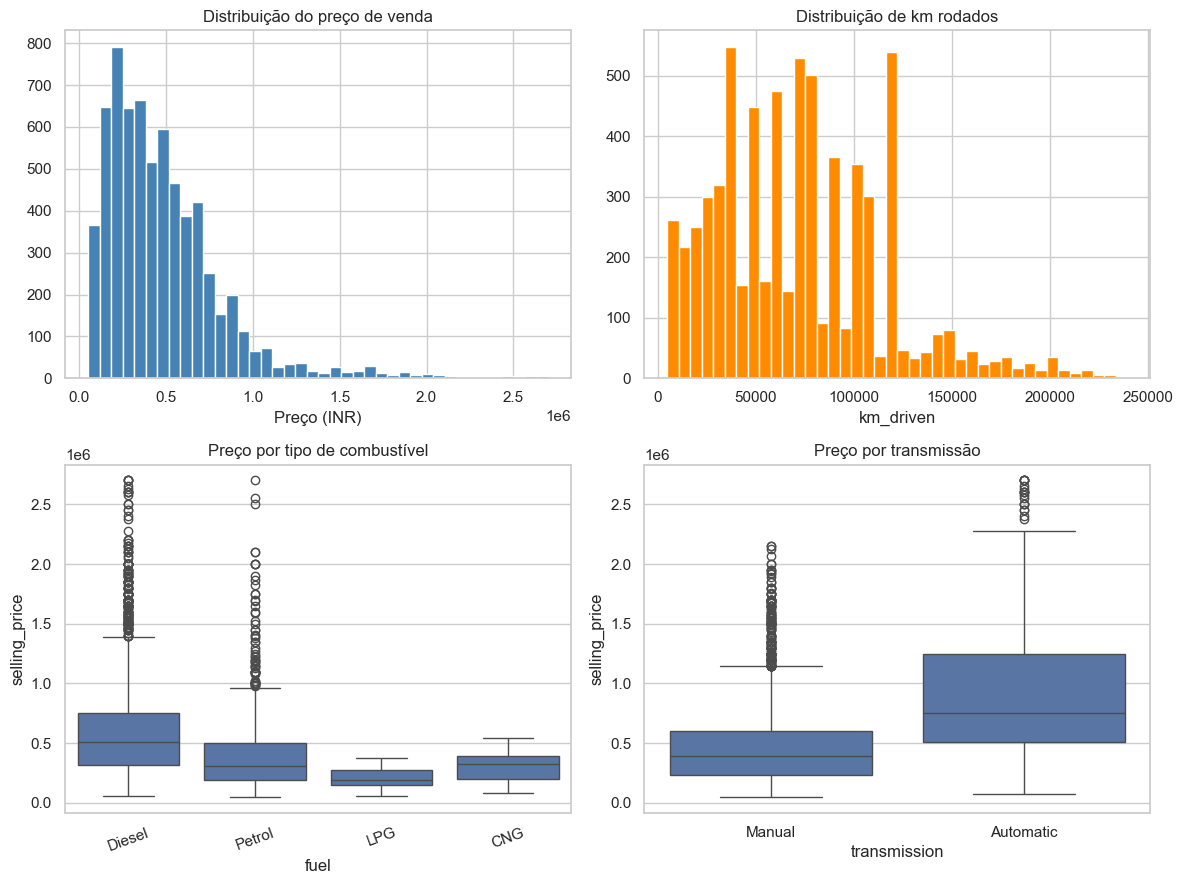

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].hist(df["selling_price"], bins=40, color="steelblue", edgecolor="white")
axes[0, 0].set_title("Distribuição do preço de venda")
axes[0, 0].set_xlabel("Preço (INR)")

axes[0, 1].hist(df["km_driven"], bins=40, color="darkorange", edgecolor="white")
axes[0, 1].set_title("Distribuição de km rodados")
axes[0, 1].set_xlabel("km_driven")

sns.boxplot(data=df, x="fuel", y="selling_price", ax=axes[1, 0])
axes[1, 0].set_title("Preço por tipo de combustível")
axes[1, 0].tick_params(axis="x", rotation=20)

sns.boxplot(data=df, x="transmission", y="selling_price", ax=axes[1, 1])
axes[1, 1].set_title("Preço por transmissão")

plt.tight_layout()
plt.show()


### Gráficos 2.1 — Histogramas e boxplots

**Histograma de preço (canto superior esquerdo)**
- Forma assimétrica à direita = muitos carros baratos/intermediários e poucos muito caros.
- Isso explica por que o RMSE pode parecer "alto" em valor absoluto — erros em caros pesam mais.

**Histograma de km (canto superior direito)**
- A maioria dos veículos concentra-se em faixas médias de uso.
- Cauda longa à direita = carros muito rodados.

**Boxplot preço × combustível (inferior esquerdo)**
- Compare medianas (linha no meio da caixa): Diesel costuma ter preços medianos diferentes de Petrol.
- Pontos fora dos "bigodes" são outliers remanescentes.

**Boxplot preço × transmissão (inferior direito)**
- Automatic geralmente aparece com preços mais altos — transmissão automática é feature premium em carros usados na Índia.


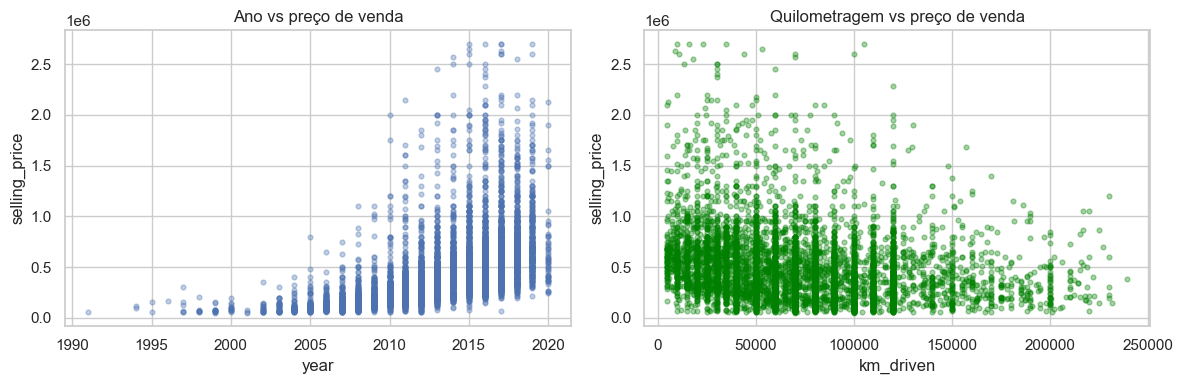

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(df["year"], df["selling_price"], alpha=0.35, s=12)
axes[0].set_title("Ano vs preço de venda")
axes[0].set_xlabel("year")
axes[0].set_ylabel("selling_price")

axes[1].scatter(df["km_driven"], df["selling_price"], alpha=0.35, s=12, color="green")
axes[1].set_title("Quilometragem vs preço de venda")
axes[1].set_xlabel("km_driven")
axes[1].set_ylabel("selling_price")

plt.tight_layout()
plt.show()


### Gráficos 2.2 — Scatter plots

**Ano vs preço (esquerda)**
- Tendência positiva esperada: carros mais novos → preços maiores.
- A nuvem é dispersa porque marca, potência e km também influenciam.

**Km vs preço (direita)**
- Tendência negativa esperada: mais km → menor preço.
- A relação não é perfeita — um carro novo com muitos km (ex.: frota) pode ser exceção.

**Pergunta para você:** essas duas relações fazem sentido economicamente? Se sim, são bons sinais de que o dataset é coerente.


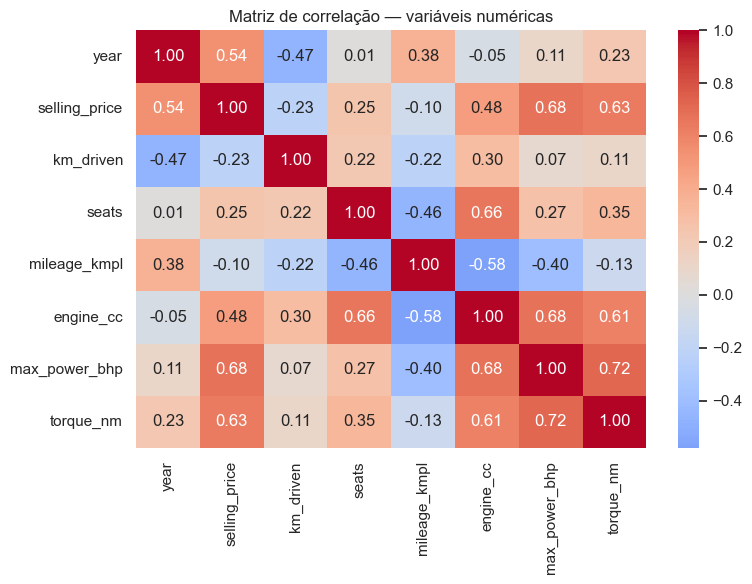

In [6]:
corr = df[numeric_cols].corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlação — variáveis numéricas")
plt.tight_layout()
plt.show()


### Gráfico 2.3 — Heatmap de correlação

Leia assim:
- **Vermelho (+1)**: variáveis crescem juntas. Ex.: `engine_cc`, `max_power_bhp` e `torque_nm` tendem a ser altamente correlacionadas (motor maior → mais potência/torque).
- **Azul (−1)**: uma sobe, outra desce. Ex.: `year` vs `km_driven` (carros mais antigos tendem a ter mais km).
- **Próximo de 0**: pouca relação linear.

**Atenção:** `selling_price` correlacionado com `year` não significa que ano *causa* preço isoladamente — pode haver confusão com marca e equipamentos.

Na seção 2.5 veremos essas relações de forma multivariada (PCA).


## 2.5 Análise multivariada exploratória (PCA)

### Passo 2.5 — Visão multivariada (inspirada no trabalho de imóveis em R)

A PCA resume colunas numéricas em eixos novos (PC1, PC2...). **Excluímos `selling_price`** para estudar características dos veículos sem incluir o alvo.

| Conceito | Significado prático |
|----------|---------------------|
| PC1 | Maior variação nos dados (ex.: desempenho/idade) |
| PC2 | Segunda direção independente (ex.: uso/consumo) |
| Scree plot | Quantos eixos valem a pena interpretar |
| Círculo de correlação | Quais variáveis "andam juntas" no plano PC1×PC2 |


In [7]:
PCA_FEATURES = [
    "year", "km_driven", "seats",
    "mileage_kmpl", "engine_cc", "max_power_bhp", "torque_nm",
]


def prepare_pca_matrix(data, features=PCA_FEATURES):
    """Seleciona variáveis numéricas, remove constantes e imputa missing."""
    matrix = data[features].copy()
    matrix = matrix.loc[:, matrix.std(skipna=True) > 0]
    matrix = matrix.dropna()
    return matrix


def fit_pca(matrix, n_components=None):
    """PCA com padronização (equivalente a scale.unit=TRUE no R)."""
    n_components = n_components or min(len(PCA_FEATURES), matrix.shape[0], matrix.shape[1])
    scaler = StandardScaler()
    scaled = scaler.fit_transform(matrix)
    pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
    pca.fit(scaled)
    return pca, scaled, matrix.columns.tolist()


def pca_correlations(pca):
    """Correlação variável × componente (base do círculo de correlação)."""
    return pca.components_.T * np.sqrt(pca.explained_variance_)


def variable_contrib_pct(corr_matrix, axis=0):
    """Contribuição percentual de cada variável a um componente."""
    values = corr_matrix[:, axis] ** 2
    return (values / values.sum()) * 100


def print_pca_summary(pca, title=""):
    eig = pd.DataFrame({
        "eigenvalue": pca.explained_variance_,
        "variance_pct": pca.explained_variance_ratio_ * 100,
        "cumulative_pct": np.cumsum(pca.explained_variance_ratio_) * 100,
    })
    print(f"\n{'=' * 70}")
    print(f"RESUMO PCA {title}".strip())
    print("=" * 70)
    display(eig.round(2))
    n_80 = np.argmax(eig["cumulative_pct"] >= 80) + 1
    n_90 = np.argmax(eig["cumulative_pct"] >= 90) + 1
    print(f"Componentes para 80% da variância: {n_80}")
    print(f"Componentes para 90% da variância: {n_90}")


pca_matrix = prepare_pca_matrix(df)
pca_full, _, pca_feature_names = fit_pca(pca_matrix)
corr_full = pca_correlations(pca_full)
print_pca_summary(pca_full, "— Base completa")


RESUMO PCA — Base completa


,eigenvalue,variance_pct,cumulative_pct
0,3.07,43.86,43.86
1,1.69,24.12,67.99
2,0.85,12.12,80.11
3,0.72,10.26,90.37
4,0.31,4.50,94.87
5,0.20,2.79,97.66
6,0.16,2.34,100.00


Componentes para 80% da variância: 3
Componentes para 90% da variância: 4


### Tabela de autovalores — o que cada coluna significa

| Coluna | Significado |
|--------|-------------|
| `eigenvalue` | Variância capturada por cada componente |
| `variance_pct` | % da variância total explicada por esse PC |
| `cumulative_pct` | Soma acumulada — quanto dos dados já foi "explicado" |

**Linhas de corte impressas (80% e 90%):** indicam quantos componentes você precisaria para reter a maior parte da informação. Não vamos usar PCA para modelar preço aqui — apenas para **entender estrutura**.

**Como analisar:** se PC1 + PC2 já somam ~50–60%, duas dimensões resumem bem o dataset.


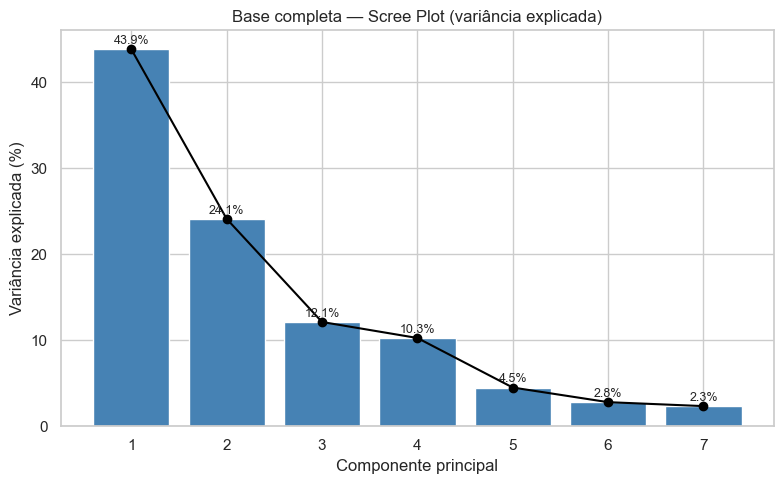

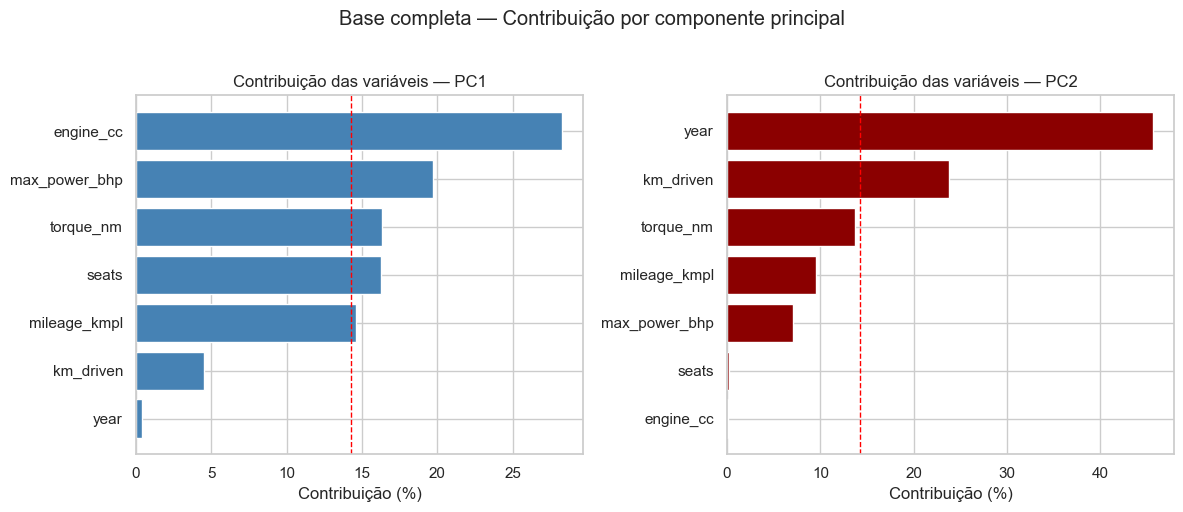

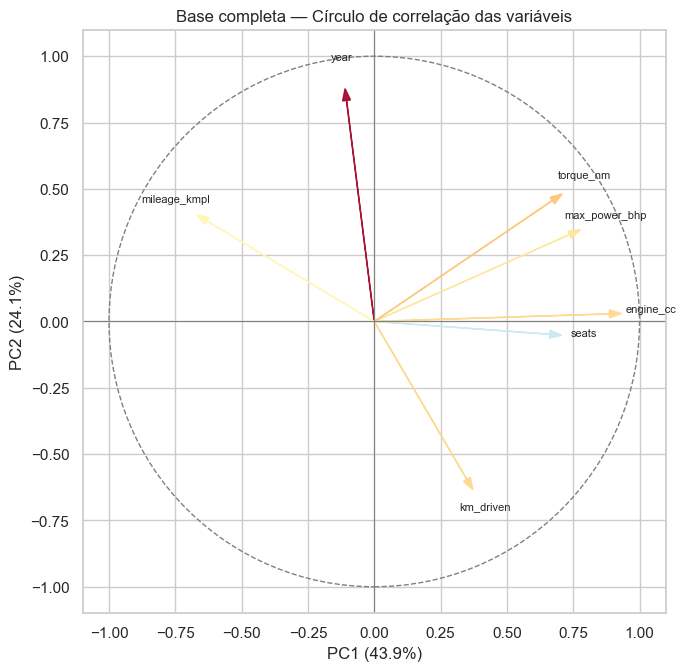

In [8]:
def plot_scree(pca, title, color="steelblue", save_path=None):
    ratios = pca.explained_variance_ratio_ * 100
    dims = np.arange(1, len(ratios) + 1)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(dims, ratios, color=color, edgecolor="white")
    ax.plot(dims, ratios, color="black", marker="o")
    for dim, value in zip(dims, ratios):
        ax.text(dim, value + 0.6, f"{value:.1f}%", ha="center", fontsize=9)
    ax.set_xlabel("Componente principal")
    ax.set_ylabel("Variância explicada (%)")
    ax.set_title(title)
    ax.set_xticks(dims)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


def plot_contrib_pair(corr_matrix, feature_names, title, save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, axis, color, pc_label in [
        (axes[0], 0, "steelblue", "PC1"),
        (axes[1], 1, "darkred", "PC2"),
    ]:
        contrib = variable_contrib_pct(corr_matrix, axis=axis)
        contrib_df = pd.DataFrame({"feature": feature_names, "contrib_pct": contrib})
        contrib_df = contrib_df.sort_values("contrib_pct", ascending=True)
        ax.barh(contrib_df["feature"], contrib_df["contrib_pct"], color=color)
        ax.axvline(100 / len(feature_names), color="red", linestyle="--", linewidth=1)
        ax.set_title(f"Contribuição das variáveis — {pc_label}")
        ax.set_xlabel("Contribuição (%)")
    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


def plot_corr_circle_on_ax(ax, corr_matrix, feature_names, pca, title):
    x = corr_matrix[:, 0]
    y = corr_matrix[:, 1]
    weights = (
        variable_contrib_pct(corr_matrix, 0) + variable_contrib_pct(corr_matrix, 1)
    )

    circle = plt.Circle((0, 0), 1, fill=False, color="grey", linestyle="--")
    ax.add_patch(circle)

    for xi, yi, name, weight in zip(x, y, feature_names, weights):
        ax.arrow(
            0, 0, xi, yi,
            head_width=0.03,
            length_includes_head=True,
            color=plt.cm.RdYlBu_r(weight / weights.max()),
            alpha=0.9,
        )
        ax.text(xi * 1.12, yi * 1.12, name, fontsize=8, ha="center")

    ax.axhline(0, color="grey", linewidth=0.8)
    ax.axvline(0, color="grey", linewidth=0.8)
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)")
    ax.set_title(title)
    ax.set_aspect("equal")


def plot_corr_circle(corr_matrix, feature_names, pca, title, save_path=None):
    fig, ax = plt.subplots(figsize=(7, 7))
    plot_corr_circle_on_ax(ax, corr_matrix, feature_names, pca, title)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


plot_scree(
    pca_full,
    "Base completa — Scree Plot (variância explicada)",
    save_path=OUTPUT_DIR / "pca_scree_full.png",
)

plot_contrib_pair(
    corr_full,
    pca_feature_names,
    "Base completa — Contribuição por componente principal",
    save_path=OUTPUT_DIR / "pca_contrib_full.png",
)

plot_corr_circle(
    corr_full,
    pca_feature_names,
    pca_full,
    "Base completa — Círculo de correlação das variáveis",
    save_path=OUTPUT_DIR / "pca_circle_full.png",
)

### Gráficos 2.5.1–2.5.3 — Scree, contribuição e círculo de correlação

**Scree plot**
- Barras decrescentes = cada PC explica menos que o anterior.
- Procure o "cotovelo" (queda acentuada → depois suave): PCs à esquerda do cotovelo são os mais informativos.
- PC1 alto (~40%+) = uma dimensão dominante (comum em dados de veículos).

**Contribuição PC1 e PC2 (gráficos lado a lado)**
- Mostra quais variáveis *mais pesam* em cada componente.
- Linha tracejada vermelha = contribuição média esperada se todas fossem iguais.
- Barras acima da linha = variáveis-chave daquele eixo.
- Espere `year`, `max_power_bhp` e `torque_nm` fortes no PC1; `km_driven` e `mileage_kmpl` podem aparecer mais no PC2.

**Círculo de correlação**
- Cada seta = uma variável projetada no plano PC1×PC2.
- Setas na **mesma direção** → variáveis positivamente correlacionadas.
- Setas em **direções opostas** → correlacionadas negativamente.
- Setas **perpendiculares** → pouca correlação linear.
- Cores mais quentes = maior contribuição aos dois primeiros PCs.
- Círculo tracejado = limite teórico de correlação (setas curtas = variável mal representada neste plano 2D).


Petrol: 2,861 registros

RESUMO PCA — Petrol


,eigenvalue,variance_pct,cumulative_pct
0,2.86,40.82,40.82
1,1.93,27.59,68.41
2,1.01,14.41,82.82
3,0.55,7.92,90.73
4,0.32,4.63,95.36
5,0.28,3.97,99.33
6,0.05,0.67,100.00


Componentes para 80% da variância: 3
Componentes para 90% da variância: 4
Diesel: 3,522 registros

RESUMO PCA — Diesel


,eigenvalue,variance_pct,cumulative_pct
0,3.02,43.18,43.18
1,1.91,27.32,70.50
2,0.89,12.67,83.18
3,0.54,7.68,90.86
4,0.28,3.95,94.81
5,0.21,2.96,97.77
6,0.16,2.23,100.00


Componentes para 80% da variância: 3
Componentes para 90% da variância: 4


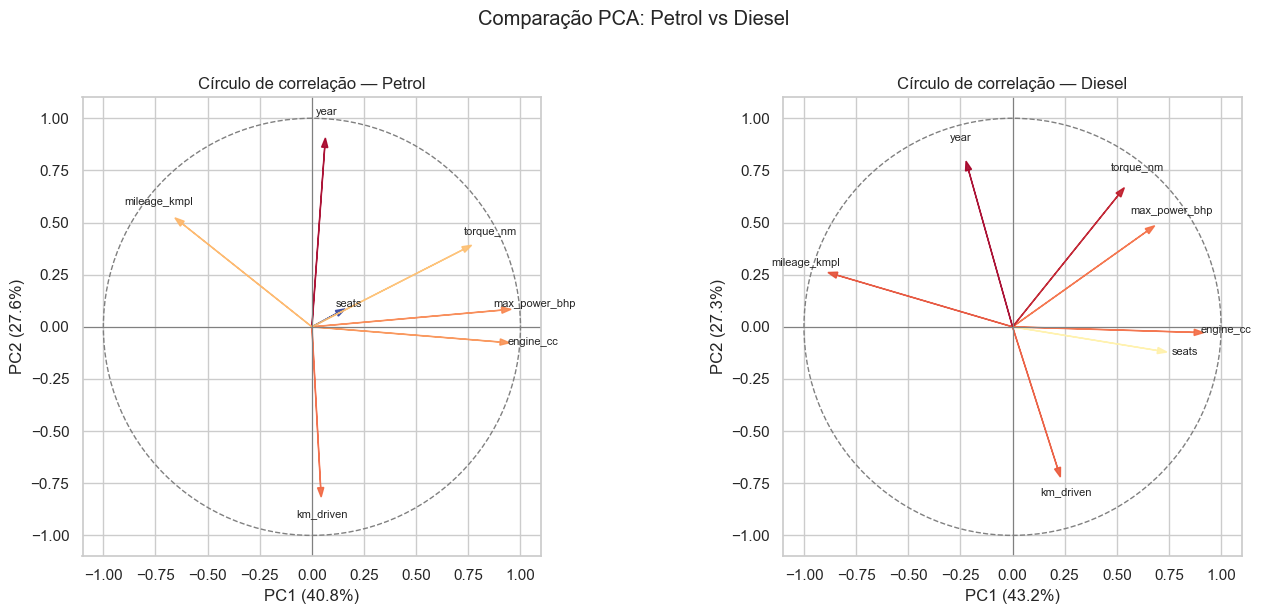

In [9]:
def run_segment_pca(data, fuel_type):
    segment = data[data["fuel"] == fuel_type]
    matrix = prepare_pca_matrix(segment)
    pca, _, feature_names = fit_pca(matrix)
    return pca, pca_correlations(pca), feature_names, len(matrix)


segments = {}
for fuel in ["Petrol", "Diesel"]:
    pca_seg, corr_seg, names_seg, n_rows = run_segment_pca(df, fuel)
    segments[fuel] = {"pca": pca_seg, "corr": corr_seg, "names": names_seg, "n": n_rows}
    print(f"{fuel}: {n_rows:,} registros")
    print_pca_summary(pca_seg, f"— {fuel}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, fuel, color in [
    (axes[0], "Petrol", "#00AFBB"),
    (axes[1], "Diesel", "#FC4E07"),
]:
    seg = segments[fuel]
    plot_corr_circle_on_ax(
        ax,
        seg["corr"],
        seg["names"],
        seg["pca"],
        f"Círculo de correlação — {fuel}",
    )

plt.suptitle("Comparação PCA: Petrol vs Diesel", y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "pca_circle_petrol_diesel.png", dpi=150, bbox_inches="tight")
plt.show()

### Gráfico 2.5.4 — Comparação Petrol vs Diesel

Mesmo tipo de círculo de correlação, mas calculado **separadamente** para cada combustível — como "aluguel vs venda" no trabalho de imóveis.

**Como comparar os dois painéis:**
- Direções similares das setas → estrutura parecida entre Petrol e Diesel.
- Diferenças no % de PC1/PC2 (nos eixos) → um segmento é mais "homogêneo" que o outro.
- Se `max_power_bhp` e `torque_nm` apontam juntas nos dois → atributos de motor importam em ambos os mercados.

**Insight prático:** se os círculos forem muito parecidos, um único modelo geral pode bastar; se forem muito diferentes, segmentar por combustível poderia ajudar (não testamos isso aqui).


## 3. Preparação para modelagem

### Passo 3 — Da exploração ao pipeline de ML

1. **Split 80/20** — treino para aprender; teste para avaliação final.
2. **Imputação** — mediana (numéricas) e moda (categóricas).
3. **StandardScaler** — mesma escala para numéricas.
4. **OneHotEncoder** — categorias viram colunas binárias.

Tudo em um `Pipeline` scikit-learn para evitar vazamento de informação do teste para o treino.


In [10]:
TARGET = "selling_price"

numeric_features = [
    "year", "km_driven", "seats",
    "mileage_kmpl", "engine_cc", "max_power_bhp", "torque_nm",
]
categorical_features = ["fuel", "seller_type", "transmission", "owner", "brand"]

feature_cols = numeric_features + categorical_features
model_df = df[feature_cols + [TARGET]].copy()

X = model_df[feature_cols]
y = model_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Amostras de treino: {len(X_train):,}")
print(f"Amostras de teste: {len(X_test):,}")


Amostras de treino: 5,330
Amostras de teste: 1,333


### Split treino/teste

- **Treino (~5.330):** usado para aprender padrões e na validação cruzada.
- **Teste (~1.333):** reservado para avaliação final — simula carros "nunca vistos".

A proporção 80/20 é padrão para datasets deste tamanho. O `random_state=42` garante reprodutibilidade.


In [11]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)


def build_pipeline(model):
    return Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])


def evaluate_model(name, pipeline, X_train, y_train, X_test, y_test):
    cv = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring=["neg_mean_absolute_error", "neg_root_mean_squared_error", "r2"],
        return_train_score=False,
    )

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    results = {
        "modelo": name,
        "cv_mae": -cv["test_neg_mean_absolute_error"].mean(),
        "cv_mae_std": cv["test_neg_mean_absolute_error"].std(),
        "cv_rmse": -cv["test_neg_root_mean_squared_error"].mean(),
        "cv_rmse_std": cv["test_neg_root_mean_squared_error"].std(),
        "cv_r2": cv["test_r2"].mean(),
        "cv_r2_std": cv["test_r2"].std(),
        "test_mae": mean_absolute_error(y_test, y_pred),
        "test_rmse": float(np.sqrt(mean_squared_error(y_test, y_pred))),
        "test_r2": r2_score(y_test, y_pred),
    }
    return results, pipeline


### Função `evaluate_model` — métricas que você vai ver

| Métrica | O que mede | Como interpretar |
|---------|------------|------------------|
| **MAE** | Erro médio absoluto (INR) | "Em média, erro de X rúpias." Mais intuitivo. |
| **RMSE** | Raiz do erro quadrático médio | Penaliza erros grandes. Sempre ≥ MAE. |
| **R²** | Fração da variância explicada | 0 = modelo inútil; 1 = predição perfeita; 0,85+ = muito bom |

**CV (cross-validation 5-fold):** divide o treino em 5 partes, treina 5 vezes e média os resultados — estimativa mais confiável que um único split.


## 4. Modelagem com cross-validation

### Passo 4 — Treinar e comparar algoritmos

| Modelo | Papel |
|--------|-------|
| Regressão Linear | Baseline — relações aproximadamente lineares |
| Random Forest | Não-linearidades e interações (marca × ano × potência) |
| KNN | Preço baseado em carros "vizinhos" parecidos |

**Validação cruzada 5-fold:** resultado mais estável que um único split.


In [12]:
models = {
    "Regressão Linear": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=20,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "KNN": KNeighborsRegressor(n_neighbors=7, weights="distance"),
}

all_results = []
fitted = {}

for name, estimator in models.items():
    pipe = build_pipeline(estimator)
    res, fitted_pipe = evaluate_model(name, pipe, X_train, y_train, X_test, y_test)
    all_results.append(res)
    fitted[name] = fitted_pipe
    print(
        f"{name}: CV MAE={res['cv_mae']:,.0f} | CV RMSE={res['cv_rmse']:,.0f} | CV R²={res['cv_r2']:.3f}"
    )

results_df = pd.DataFrame(all_results).set_index("modelo")
results_df.round(3)


Regressão Linear: CV MAE=109,243 | CV RMSE=158,454 | CV R²=0.790
Random Forest: CV MAE=71,304 | CV RMSE=116,317 | CV R²=0.887
KNN: CV MAE=81,261 | CV RMSE=131,306 | CV R²=0.856


,cv_mae,cv_mae_std,cv_rmse,cv_rmse_std,cv_r2,cv_r2_std,test_mae,test_rmse,test_r2
modelo,,,,,,,,,
Regressão Linear,109242.529,4154.214,158453.725,7700.842,0.790,0.016,110375.996,164388.092,0.784
Random Forest,71304.293,2127.757,116317.323,3193.230,0.887,0.004,68755.880,117420.362,0.890
KNN,81260.924,1142.204,131306.230,4227.726,0.856,0.011,81103.792,132221.694,0.860


### Tabela de resultados — o que comparar primeiro

1. Olhe **CV R²** — desempenho médio no treino (mais confiável).
2. Depois **test R²** — confirma se não houve overfitting grave.
3. Se CV e teste forem próximos → modelo generaliza bem.
4. Se teste << CV → possível overfitting.

**Valores esperados neste dataset:** Random Forest tipicamente lidera; Regressão Linear fica atrás; KNN no meio.


## 5. Comparação de desempenho

### Passo 5 — Qual modelo escolher?

Compare **MAE**, **RMSE** e **R²** da validação cruzada nos gráficos abaixo:

- **MAE/RMSE menores** = melhor
- **R² maior** = melhor

O modelo com menor **RMSE na CV** é referência na seção 6.


,cv_mae,cv_rmse,cv_r2
modelo,,,
Regressão Linear,109242.529,158453.725,0.790
Random Forest,71304.293,116317.323,0.887
KNN,81260.924,131306.230,0.856


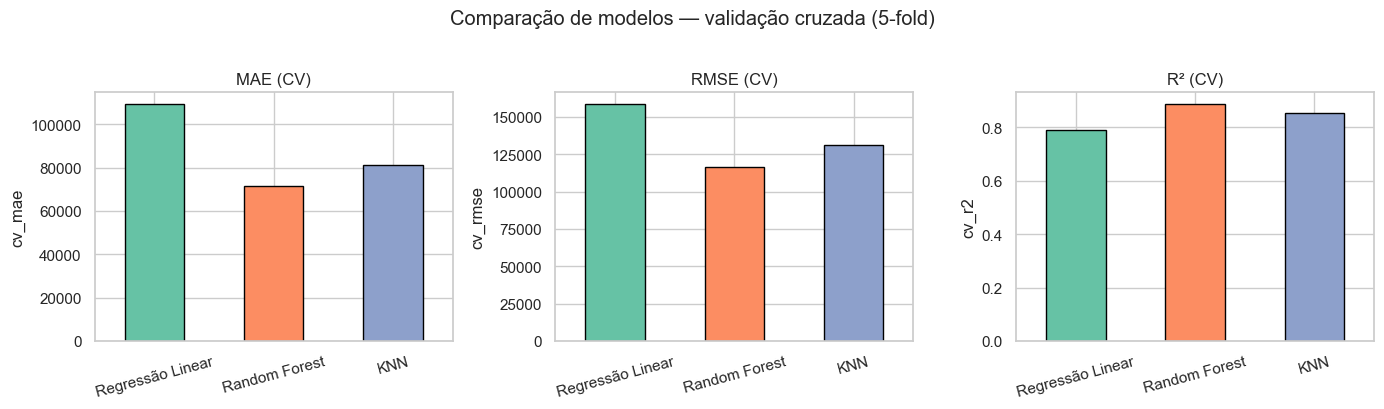

Melhor modelo (menor RMSE na CV): Random Forest


In [13]:
metrics = ["cv_mae", "cv_rmse", "cv_r2"]
display(results_df[metrics].round(3))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = sns.color_palette("Set2", n_colors=len(results_df))

for ax, metric, title in zip(
    axes,
    ["cv_mae", "cv_rmse", "cv_r2"],
    ["MAE (CV)", "RMSE (CV)", "R² (CV)"],
):
    results_df[metric].plot(kind="bar", ax=ax, color=colors, edgecolor="black")
    ax.set_title(title)
    ax.set_ylabel(metric)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=15)

plt.suptitle("Comparação de modelos — validação cruzada (5-fold)", y=1.02)
plt.tight_layout()
plt.show()

best_model_name = results_df["cv_rmse"].idxmin()
print(f"Melhor modelo (menor RMSE na CV): {best_model_name}")


### Escolha do melhor modelo

A linha impressa abaixo indica qual algoritmo venceu na CV. Normalmente é o **Random Forest**, pois:
- Relações preço × ano × potência não são estritamente lineares.
- Interações entre `brand` (one-hot) e variáveis numéricas são capturadas pelas árvores.

A Regressão Linear ainda é útil como contraste — mostra o ganho de modelos mais flexíveis.


## 6. Interpretação — importância das variáveis

### Passo 6 — O que o melhor modelo aprendeu?

1. **Importância de features** — variáveis que mais ajudaram o Random Forest.
2. **Real vs Previsto** — onde o modelo acerta ou erra.

Compare o top 5 com a PCA (seção 2.5): convergência entre EDA, PCA e modelo fortalece o relatório.


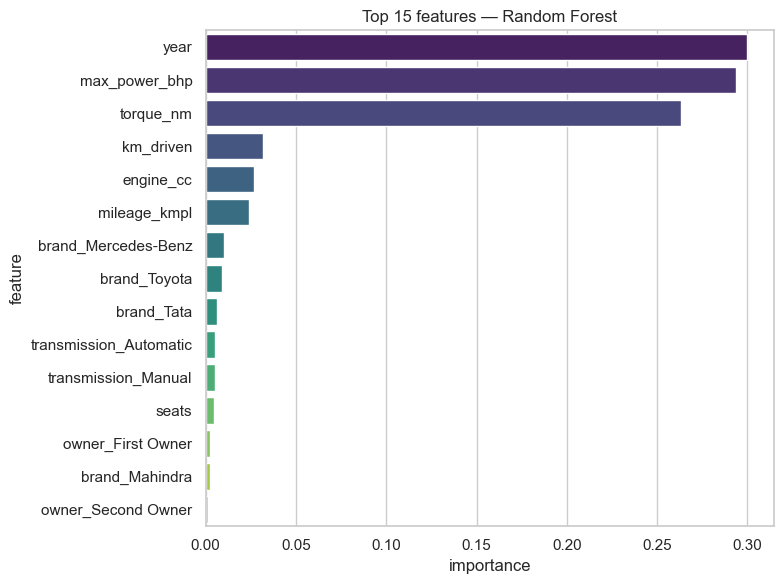

,feature,importance
0,year,0.299688
5,max_power_bhp,0.293601
6,torque_nm,0.263433
1,km_driven,0.031695
4,engine_cc,0.027010
3,mileage_kmpl,0.024212
40,brand_Mercedes-Benz,0.010121
48,brand_Toyota,0.008991
47,brand_Tata,0.006053
14,transmission_Automatic,0.004986


In [14]:
def get_feature_names(preprocessor):
    num_names = numeric_features
    cat_names = list(
        preprocessor.named_transformers_["cat"].named_steps["encoder"].get_feature_names_out(
            categorical_features
        )
    )
    return num_names + cat_names


best_pipe = fitted[best_model_name]
feature_names = get_feature_names(best_pipe.named_steps["preprocessor"])

if hasattr(best_pipe.named_steps["model"], "feature_importances_"):
    importances = best_pipe.named_steps["model"].feature_importances_
    imp_df = (
        pd.DataFrame({"feature": feature_names, "importance": importances})
        .sort_values("importance", ascending=False)
        .head(15)
    )

    plt.figure(figsize=(8, 6))
    sns.barplot(data=imp_df, y="feature", x="importance", palette="viridis")
    plt.title(f"Top 15 features — {best_model_name}")
    plt.tight_layout()
    plt.show()
    display(imp_df)
else:
    coefs = best_pipe.named_steps["model"].coef_
    coef_df = (
        pd.DataFrame({"feature": feature_names, "coeficiente": coefs})
        .assign(abs_coef=lambda d: d["coeficiente"].abs())
        .sort_values("abs_coef", ascending=False)
        .head(15)
    )
    display(coef_df[["feature", "coeficiente"]])


### Gráfico de importância

- Barras maiores = variável mais usada para dividir os dados nas árvores.
- Features de `brand_*` fragmentadas (uma barra por marca) indicam que marca importa, mas de forma desigual (Mercedes ≠ Maruti).
- **Não confunda com causalidade:** importância alta significa poder preditivo, não necessariamente que alterar a variável muda o preço na vida real.

**Para o relatório:** cite o top 5 e relate com os achados da EDA e da PCA.


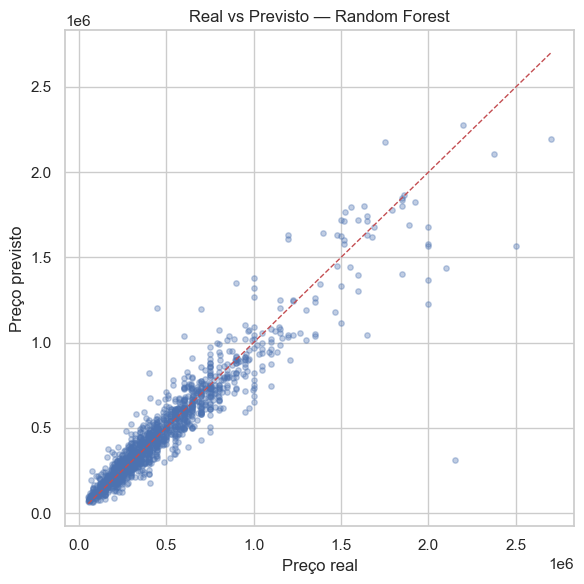

Resumo final no conjunto de teste:


,test_mae,test_rmse,test_r2
modelo,,,
Regressão Linear,110375.996,164388.092,0.784
Random Forest,68755.880,117420.362,0.890
KNN,81103.792,132221.694,0.860


In [15]:
y_pred_best = best_pipe.predict(X_test)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred_best, alpha=0.35, s=15)
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
ax.plot(lims, lims, "r--", lw=1)
ax.set_xlabel("Preço real")
ax.set_ylabel("Preço previsto")
ax.set_title(f"Real vs Previsto — {best_model_name}")
plt.tight_layout()
plt.show()

print("Resumo final no conjunto de teste:")
display(results_df[["test_mae", "test_rmse", "test_r2"]].round(3))


### Gráfico Real vs Previsto

- Eixo X = preço verdadeiro; Eixo Y = preço que o modelo chutou.
- Linha diagonal vermelha = predição perfeita.
- Pontos **sobre** a diagonal = modelo superestimou o preço.
- Pontos **abaixo** = subestimou.

**Padrões a notar:**
- Dispersão maior nos preços altos → erros maiores em carros de luxo (menos exemplos no treino).
- Nuvem apertada na diagonal central → bom desempenho na faixa de preço mais comum.

A tabela abaixo do gráfico resume MAE, RMSE e R² no **conjunto de teste** — números finais para o artigo.


## 7. Conclusões e roteiro para o relatório

### Síntese do fluxo

```text
Limpeza → EDA → PCA → Pipeline → 3 modelos + CV → Interpretação
```

### Principais achados

- Dataset adequado após limpeza (~6.663 registros).
- **EDA:** preços assimétricos; ano (+) e km (−) associados ao preço.
- **PCA:** variáveis de motor agrupam-se; Petrol e Diesel com estruturas similares.
- **Random Forest** lidera (R² ~0,89 no teste).

### Checklist seminário (15 min)

1. Problema e dataset (2 min)
2. EDA + PCA — 2–3 gráficos (4 min)
3. Modelos e métricas (5 min)
4. Interpretação e conclusão (3 min)
5. Perguntas (1 min)
